# Курс "Практикум по математической статистике"

# 3 курс ФПМИ МФТИ, осень 2025
## Практическое задание 2. Доверительное оценивание, бутстреп, робастные методы
### Дедлайн --- 18 октября, 16:00

Это обязательное домашнее задание нашего курса. Мы предлагаем выполнять задания прямо в этом ноутбуке. Пожалуйста, не стирайте условия задач.

Сдавать ноутбук нужно будет в LMS.

---

В этом и последующих заданиях вам потребуется выполнять генерацию случайных величин из некоторого распределения, моделирование оценок параметров и проверку их теоретических свойств на практике. Для этого вам понадобится библиотека scipy.stats. Мы настоятельно рекомендуем для генерации выборок использовать именно эту библиотеку.

Настоятельно рекомендуемая форма оформления домашних заданий — это Jupyter Notebook и его pdf-версия с:

* условием задачи,
* решением (если требуется некоторый теоретический вывод),
* описанием плана решения, который потом реализуется в коде,
* собственно кодом,
* построенными графиками (если это требуется) и **выводом**, который как правило должен заключаться в объяснении практических результатов с использованием теоретических фактов. ***Вывод требуется даже в том случае, если в условии об этом явно не сказано!***
* некоторыми другими вещами, если об этом будет указано в задании.

Оценка за каждую задачу складывается из правильного выполнения всех этих пунктов. Закрывая на них глаза, вы сознательно понижаете свою оценку.

Каждая задача оценивается в 10 баллов.



In [7]:
import pandas as pd
import numpy as np
from scipy import stats as sps

from matplotlib import pyplot as plt
import seaborn as sns

sns.set(style="darkgrid", font_scale=1.4)

**Дисклеймер**:
В задачах будет разбиение на пункты, но оцениваться задача будет **целиком**. Можете считать, что выполнение всех пунктов вместе с отсутствием замечаний по полноте анализа/эффективности кода/информативности графиков/т.д. приносит полный балл.

## Задача 1

В случаях, когда ошибка в значении параметра может дорого обойтись, применяют доверительное оценивание. Вместо точечного значения параметра оценкой является отрезок, который с высокой вероятностью накрывает истинное значение параметра. Эту вероятность ещё называют *уровнем доверия*. В рамках этого ноутбука установим его равным $\gamma = 0.95$.

В этой задаче мы посмотрим на разные подходы в построении ДИ.

- В каждом из пунктов ниже сгенерируйте выборку $X_1, ...,X_{100}$ из распределения $\mathsf P_\theta$. Для уровня доверия $\gamma$ и всех $n \leq 100$ изобразите на графиках в координатах $(n, \theta)$:
    - Доверительный интервал для параметра $\theta$. Его нужно построить по первым $n$ элементам выборки, теоретически обосновать и написать;
    - График оценки $\widehat{\theta}_n$;
    - Истинное значение параметра $\theta$.

- Для отрисовки доверительного интервала используйте `plt.fill_between`. Не забудьте про параметр `alpha`.

- Для того, чтобы избежать дублирования кода, рекомендуем написать функцию `draw_confidence_interval`, изображающую на графике все необходимое.

- В каждом случае при помощи моделирования проверьте, как часто параметр действительно попадает в свой доверительный интервал: сгенерируйте $N$ (чему равно $N$ -- см. ниже) выборок размера 100, по каждой из них постройте доверительный интервал и проверьте, накрыли ли в очередной раз параметр или нет. Таким образом, мы получим выборку из $\mathrm{Bern}(p)$ размера $N$, где $p$ --- истинная вероятность накрытия (которая может немного отличаться от взятой $\gamma$). В свою очередь для правильного оценивания $p$ мы тоже можем построить ДИ. Для этого перед началом выполнения пунктов:
    - Выпишите асимптотический ДИ у.д. $\gamma$ для параметра $p$, используя выборочное среднее как асимптотически нормальную оценку. Для удобства оформите вычисление этого ДИ в виде функции `confint_bern(k, N)`, где `k` --- число попаданий в ДИ.
    - Нам хотелось бы, чтобы полученный при моделировании интервал для $p$ был не слишком большим. Договоримся, чтобы его радиус не превышал $0.01$. Какое минимальное $N$ надо взять, чтобы наши хотелки были **гарантировано** удовлетворены? Найдите его и используйте именно это значение для числа выборок.
    - Полученный для $p$ интервал впишите в название графика.

Пусть $Y_i = I${ДИ покрыл парметр на i-ом запуске}. Тогда $Y_i \sim Bern(p)$ и $Y_i$ - i.i.d. \
 $\hat Y$ := $\frac{1}{N} \sum_{i=1}^N Y_i = \frac{k}{N}$, где k - кол-во попаданий. \
 $\sqrt{N}(\hat Y - p) \xrightarrow{d} N(0, p(p-1))$ \
 Тогда доверительный интервал уровня $\gamma = 1 - \alpha$: [$\hat Y - z_{1 - \frac{\alpha}{2}}*C$, $\hat Y + z_{1 - \frac{\alpha}{2}}*C$], \
  где C := $\sqrt{\frac{\hat Y (1 - \hat Y)}{N}}$ и $z_{1 - \frac{\alpha}{2}}$ - квантиль стандратного нормального распределения \
По условию радиус не больше 0.01 - значит $z_{1 - \frac{\alpha}{2}} * C \le 0.01$  $\Longrightarrow N \ge z_{1-\alpha/2}^{2}  * \hat Y(1-\hat Y)* 10^4$.



In [8]:
def confint_bern(k, N, gamma=0.95):
    p_hat = k / N
    norm = sps.norm.ppf((1 + gamma)/2)
    C = np.sqrt(p_hat * (1 - p_hat) / N)
    left, right = p_hat - norm * C, p_hat + norm * C
    return left, right, p_hat


def min_N(p_hat, gamma=0.95):
    norm = sps.norm.ppf((1 + gamma)/2)
    return int(np.ceil((norm ** 2) * p_hat * (1 - p_hat) * 10**4))

Также будет логичным сразу написать функции которые будут генерировать выборки, вырисовывать графики и прочее

In [9]:
def draw_confidence_interval(n_grid, theta_hat, left, right, theta_true,
                             title):
    plt.figure()
    plt.fill_between(n_grid, left, right, alpha=0.5, label="Доверительный интервал")
    plt.plot(n_grid, theta_hat, lw=2, label=r"$\hat{\theta}_n$")
    plt.axhline(theta_true, ls="--", color='r', label=r"Истинное $\theta$")
    plt.xlabel("n")
    plt.ylabel(r"$\theta$")
    plt.title(title)
    plt.legend()
    plt.tight_layout()


def generate_samples(dist, params: dict, n = 100):
    return dist.rvs(size=n, **params)


def theta_seqs(theta, x):
    n = x.shape[0]
    return np.asarray([theta(x[:i+1]) for i in range(n)]).T

def coverage(theta, left, right):
    return np.sum((theta >= left) & (theta <= right))

1. $\mathsf{P}_{\theta} = \mathrm{U}[0, \theta]$.
- В качестве истинного значения параметра возьмите $\theta = 10$.
- ДИ постройте [методом центральной статистики](https://ru.wikipedia.org/wiki/%D0%A6%D0%B5%D0%BD%D1%82%D1%80%D0%B0%D0%BB%D1%8C%D0%BD%D0%B0%D1%8F_%D1%81%D1%82%D0%B0%D1%82%D0%B8%D1%81%D1%82%D0%B8%D0%BA%D0%B0) посредством оценки $\widehat{\theta} = \frac{n+1}{n}X_{(n)}$.
- Дополнительно объясните, зачем нужен множитель $\frac{n+1}{n}$ и почему на графике не стоит рисовать оценку $\widetilde{\theta} = X_{(n)}$.

Пусть $( X_1,\dots,X_n \sim U[0,\theta] )$.  
$T = \frac{X_n}{\theta}$
имеет распределение
$
T \sim \mathrm{Beta}(n, 1), \quad F(t) = t^n, \quad 0 < t < 1.
$ \
$\mathbb P\{a_n \le T \le b_n\} = \gamma$ , где квантили $(a_n,b_n)$ выбираются из распределения $ (\mathrm{Beta}(n,1))$:
$$a_n = (\alpha/2)^{1/n}, \qquad b_n = (1-\alpha/2)^{1/n}, \qquad \alpha = 1 - \gamma.$$
Получаем
$$
\mathbb P\left\{ a_n \le \frac{X_n}{\theta} \le b_n \right\} = \gamma.
$$
ДИ для θ:
$$
\theta \in \left[ \frac{X_n}{b_n},\ \frac{X_n}{a_n} \right].
$$

Известно, что $X_n$ - смещенная оценка:($\mathbb E[M_n] = \frac{n}{n+1}\,\theta.$). Очевидно, как сделать ее несмещенной. Поэтому на графике, смещенная будет просто ниже истинного значения, а несмещенная будет колебаться около

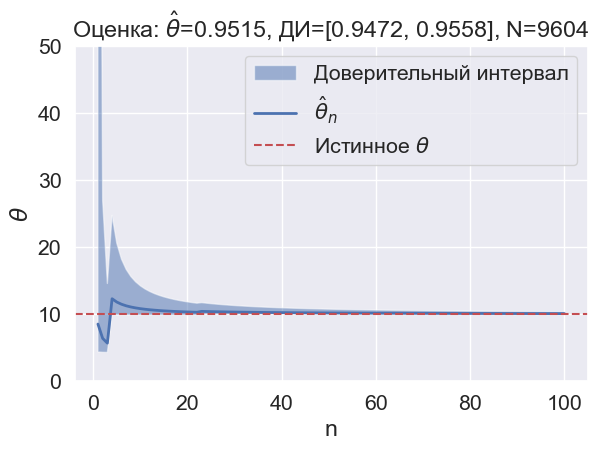

In [10]:
# YOUR CODE HERE
GAMMA = 0.95
TRUE_THETA = 10
alpha = 1 - GAMMA
n = 100
n_grid = np.arange(1, n+1)

N = min_N(1/2)
x = generate_samples(sps.uniform, {'loc':0, 'scale':TRUE_THETA})

def theta_hat(arr):
    m = len(arr)
    M = np.max(arr)
    return (m + 1) / m * M

def left_bound(arr):
    m = len(arr)
    M = float(np.max(arr))
    b_n = (1 - alpha/2.0) ** (1.0 / m)
    return M / b_n

def right_bound(arr):
    m = len(arr)
    M = np.max(arr)
    a_n = (alpha/2.0) ** (1.0 / m)
    return M / a_n

theta_hat_seq = theta_seqs(theta_hat, x)
left_seq = theta_seqs(left_bound, x)
right_seq = theta_seqs(right_bound, x)
k = 0
n = 100
for _ in range(N):
    xi = generate_samples(sps.uniform, {'loc': 0, 'scale': TRUE_THETA}, n=100)
    M = xi.max()
    a_n = (alpha/2.0) ** (1.0 / n)
    b_n = (1 - alpha/2.0) ** (1.0 / n)
    L_last = M / b_n
    R_last = M / a_n
    k += int(L_last <= TRUE_THETA <= R_last)

L_p, U_p, p_hat = confint_bern(k, N)

title = rf"Оценка: $\hat \theta$={p_hat:.4f}, ДИ=[{L_p:.4f}, {U_p:.4f}], N={N}"
draw_confidence_interval(n_grid, theta_hat_seq, left_seq, right_seq, TRUE_THETA, title)
plt.ylim(0,50)
plt.show()

2. $\mathsf P_{\theta, \sigma^2} = \mathcal{N}(\theta, \sigma^2)$.
- Здесь **оба параметра $\theta, \sigma^2$ неизвестны**, но ДИ строим для $\theta$.
- $\theta$ --- параметр сдвига, $\sigma^2$ --- дисперсия.
- В качестве истинного значения параметров возьмите $\theta = 10$, $\sigma^2 = 9$.
- ДИ постройте точный, с помощью статистики Стьюдента (см. ноутбук с лекции, теоретически обосновывать его не нужно). Для графика возьмите $\widehat{\theta} = \overline{X}$.

$$
\widehat{\theta} = \overline{X} = \frac{1}{n}\sum_{i=1}^n X_i
$$


$$T = \frac{\sqrt{n}(\overline{X} - \theta)}{S(X)}, где S(X) = \sqrt{\frac{1}{n - 1} \sum_{i=1}^n (X_i - \overline{X})^2}$$


T имеет распределение Стьюдента с n-1 степенями свободы:

$$
T \sim \mathsf{t}_{n - 1}.
$$

Для уровня доверия $ \gamma = 1 - \alpha$ возьмём симметричные квантили: $t_{\frac{\alpha}{2}}^{n - 1}, \quad t_{1 - \frac{\alpha}{2}}^{n - 1}$

Они симметричны поэтому:

$$
-t_{\frac{1 + \gamma}{2}}^{n - 1} \le 
\frac{\sqrt{n}(\overline{X} - \theta)}{S(X)} 
\le t_{\frac{1 + \gamma}{2}}^{n - 1}.
$$

Преобразуем неравенство относительно параметра \(\theta\):

$$
\mathbb{P}\left\{
\overline{X} - \frac{S(X) t_{\frac{1 + \gamma}{2}}^{n - 1}}{\sqrt{n}} 
\le \theta 
\le 
\overline{X} + \frac{S(X) t_{\frac{1 + \gamma}{2}}^{n - 1}}{\sqrt{n}}
\right\} = \gamma.
$$

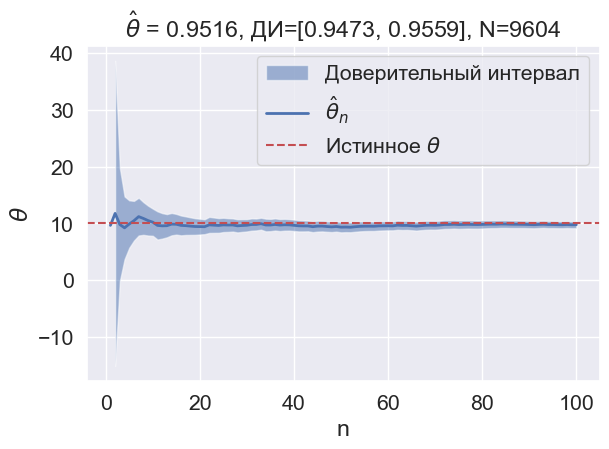

In [11]:
# YOUR CODE HERE

GAMMA = 0.95
THETA_TRUE = 10.0
SIGMA_TRUE = 3.0 
n = 100
n_grid = np.arange(1, n+1)

x = generate_samples(sps.norm, {'loc': THETA_TRUE, 'scale': SIGMA_TRUE}, n=n)

def theta_hat(arr):
    return float(np.mean(arr))

def left_bound(arr):
    m = len(arr)
    if m == 1:
        return np.nan
    xbar = float(np.mean(arr))
    s = float(np.std(arr, ddof=1))
    t = sps.t.ppf((1 + GAMMA)/2, df=m-1)
    return xbar - t * s / np.sqrt(m)

def right_bound(arr):
    m = len(arr)
    if m == 1:
        return np.nan
    xbar = float(np.mean(arr))
    s = float(np.std(arr, ddof=1))
    t = sps.t.ppf((1 + GAMMA)/2, df=m-1)
    return xbar + t * s / np.sqrt(m)

theta_hat_seq = theta_seqs(theta_hat, x)
left_seq = theta_seqs(left_bound, x)
right_seq = theta_seqs(right_bound, x)

N = min_N(1/2)

k = 0
df = n - 1
t_n = sps.t.ppf((1 + GAMMA)/2, df=df)

for _ in range(N):
    xi = generate_samples(sps.norm, {'loc': THETA_TRUE, 'scale': SIGMA_TRUE}, n=n)
    xbar = float(np.mean(xi))
    s = float(np.std(xi, ddof=1))
    L_last = xbar - t_n * s / np.sqrt(n)
    R_last = xbar + t_n * s / np.sqrt(n)
    k += int(L_last <= THETA_TRUE <= R_last)

L_p, U_p, p_hat = confint_bern(k, N, gamma=GAMMA)

title = rf"$\hat \theta$ = {p_hat:.4f}, ДИ=[{L_p:.4f}, {U_p:.4f}], N={N}"
draw_confidence_interval(n_grid, theta_hat_seq, left_seq, right_seq, THETA_TRUE, title)
plt.show()

3. $\mathsf P_{\theta, \lambda} = \Gamma(\theta, \lambda)$.
- Здесь **оба параметра $\theta, \lambda$ неизвестны**, но ДИ строим для $\theta$.
- Параметризация как в правом столбце в [Википедии](https://en.wikipedia.org/wiki/Gamma_distribution?ysclid=mefohahyxl329612880): $\theta$ --- параметр формы, $\lambda$ --- параметр интенсивности.
- В качестве истинного значения параметров возьмите $\theta = 10$, $\lambda = 4$.
- ДИ постройте с помощью асимп. нормальной оценки, а именно --- ОМП, $\widehat\theta = \widehat\theta_{MLE}$.
    - В прошлом праке вы уже научились находить ОМП численно, а из основного курса узнаете, что асимп. ковариационная матрица ОМП равна обратной матрице Фишера:
    $$
    \sqrt{n} \cdot (\widehat\theta_{MLE} - \theta) \stackrel{d}{\to} \mathcal{N}(0, I(\theta)^{-1}),$$

$$
I(\theta)_{ij} = -\mathsf E_{\theta} \frac{\partial^2}{\partial \theta_i \partial \theta_j} \ln \rho_{\theta}(X_1), \;\;\; \theta = (\theta_1, \ldots, \theta_k) \text{ --- вектор параметров}
$$
Поймите, чем можно приблизить обратную матрицу Фишера и как всё это дело посчитать численно. Возможно, функция [`scipy.optimize.minimize`](https://docs.scipy.org/doc/scipy/reference/generated/scipy.optimize.minimize.html) вам поможет.
- Дополнительно поясните, почему мы не воспользовались какими-то более простыми асимп. нормальными оценками, например, по методу моментов. В чём польза использования именно ОМП?


логарифм плотности имеет вид
$$
\ln\rho_{\theta,\lambda}(x)
= (\theta - 1)\ln x + \theta \ln \lambda - \lambda x - \ln\Gamma(\theta)
$$

частные производные:  
$$
\frac{\partial}{\partial\theta}\ln\rho_{\theta,\lambda}(x)
= \ln x + \ln\lambda - \psi(\theta), \quad
\frac{\partial}{\partial\lambda}\ln\rho_{\theta,\lambda}(x)
= \frac{\theta}{\lambda} - x,
$$
где $\psi(\theta)$ — дигамма-функция (scipy.special.digamma)(она же $\frac{\Gamma(\theta)'}{\Gamma(\theta)}$)


Мы приблизим матрицу Фишера гессианом функции NLL, которую минимизируем с помощью scipy.optimize.minimize().  
Это нетрудно заметить так как:
$$
\mathsf E\big[\nabla^2 NLL(X|\theta,\lambda)\big]
\;\approx\;
\nabla^2 NLL(X|\widehat\theta,\widehat\lambda),
$$
а обратный гессиан в точке минимума даёт оценку ОМП:
$
\approx (\nabla^2 NLL(\widehat\theta,\widehat\lambda))^{-1}
$

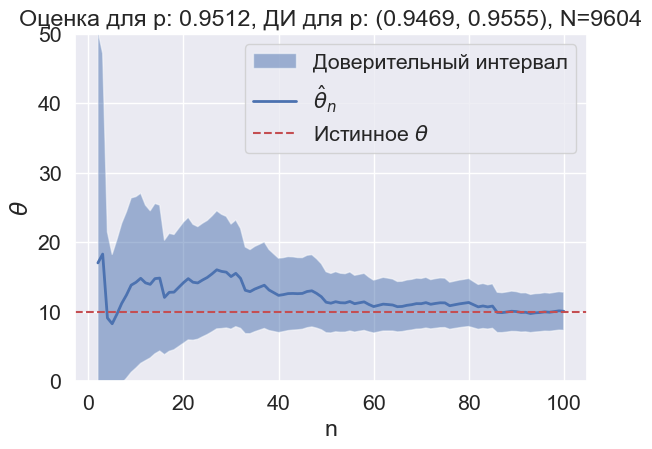

In [16]:
import scipy.optimize as opt
from scipy.special import digamma, gammaln

GAMMA = 0.95
THETA_TRUE  = 10.0 
LAMBDA_TRUE = 4.0
z = sps.norm.ppf((1 + GAMMA) / 2)

n = 100
n_grid = np.arange(1, n+1)

def log_likehood_gamma(x, theta, lambda_):
    return (theta - 1) * np.log(x) + theta * np.log(lambda_) - lambda_ * x - gammaln(theta)

def d_log_likehood_gamma(x, theta, lambda_):
    dtheta  = np.log(x) + np.log(lambda_) - digamma(theta)
    dlambda = (theta / lambda_) - x
    return dtheta, dlambda

def nll_sum(x, theta, lambda_): 
    return -np.sum(log_likehood_gamma(x, theta, lambda_))

def dnll_sum(x, theta, lambda_):
    dtheta, dlambda = d_log_likehood_gamma(x, theta, lambda_)
    return -np.array([dtheta.sum(), dlambda.sum()], dtype=float)

def mle(x, x0):
    def fun(params, xx):
        th, la = params
        return nll_sum(xx, th, la)
    def jac(params, xx):
        th, la = params
        return dnll_sum(xx, th, la)

    res = opt.minimize(fun=fun, x0=np.array(x0, dtype=float),
                       args=(x,), jac=jac, method="L-BFGS-B")
    return res

def theta_hat_fun(arr):
    xbar = float(np.mean(arr))
    var = float(np.var(arr, ddof=1))
    var= max(var, 1e-12)
    x0 = ((xbar**2) / var, xbar / var)
    res = mle(arr, x0=x0)
    return float(res.x[0]) 

def right_bound(arr):
    xbar = float(np.mean(arr))
    var = float(np.var(arr))
    var = max(var, 1e-12)
    x0 = ((xbar**2) / var, xbar / var)
    res = mle(arr, x0=x0)
    theta_hat = float(res.x[0])

    Hinv = res.hess_inv
    cov = np.array(Hinv.todense(), dtype=float)
    se_theta = float(np.sqrt(max(cov[0, 0], 0.0)))
    return theta_hat + z * se_theta

def left_bound(arr):
    theta_hat = theta_hat_fun(arr)
    right = right_bound(arr)
    return 2 * theta_hat - right

x = generate_samples(sps.gamma, {'a': THETA_TRUE, 'scale': 1.0 / LAMBDA_TRUE}, n=n)
theta_hat_seq = theta_seqs(theta_hat_fun, x)
left_seq      = theta_seqs(left_bound, x)
right_seq     = theta_seqs(right_bound, x)

N_cov = min_N(1/2)
k = 0
for _ in range(N_cov):
    xi = generate_samples(sps.gamma, {'a': THETA_TRUE, 'scale': 1.0 / LAMBDA_TRUE}, n=n)
    xbar = float(np.mean(xi))
    var = float(np.var(xi, ddof=1))
    var = max(var, 1e-12)
    x0 = ((xbar**2)/var, xbar/var)

    res = mle(xi, x0=x0)
    theta_hat = float(res.x[0])

    Hinv = res.hess_inv
    cov = np.array(Hinv.todense(), dtype=float)
    se_theta = float(np.sqrt(cov[0, 0]))

    L_last = theta_hat - z * se_theta
    R_last = theta_hat + z * se_theta
    k += int(L_last <= THETA_TRUE <= R_last)

L_p, U_p, p_hat = confint_bern(k, N_cov, gamma=GAMMA)

title = f"Оценка для p: {p_hat:.4f}, ДИ для p: ({L_p:.4f}, {U_p:.4f}), N={N_cov}"
draw_confidence_interval(n_grid, theta_hat_seq, left_seq, right_seq, THETA_TRUE, title)
plt.ylim(0, 50)
plt.show()

Сделайте вывод о том, насколько точен доверительный интервал в каждом случае? Насколько он широк? А что от него ожидается: быть шире или быть уже? От каких свойств распределения зависит ширина?

Вывод:

1. $\ U[0, \theta]$
При малых n максимум может сильно шуметь, однако при увеличении выборки быстро ширина убывает 


2. $\ N(\theta, \sigma^2)$
Ширина очевидно зависит от дисперсии, но оценка методом Стьюдента убывает как обратный корень, что крайне приятно


3. $\Gamma(\theta, \lambda)$ шире чем во втором методе, однако супер прикольно поскольку надо не так уж и много знать про распределение

По итогу ширина явно завсисит от дисперсии, но последние 2 метода устойчивы к выборосам а первый на самом деле нет.

## Задача 2. Бутстреп



На лекции мы с горем пополам научились строить бутстрепные ДИ, давайте теперь поймём, какие из них более точны. В этом пункте вы будете строить различные ДИ для корня из дисперсии a.k.a стандартного отклонения (std); вам предлагается моделированием оценить вероятность накрытия ими истинного значения std распределения в зависимости от размера выборки. Вот примерный план:
- Выберете сами распределение, которое на ваш взгляд будет достаточно репрезентативным в контексте сравнения ДИ для std. Поясните ваш выбор. *Замечание.* Давайте договоримся, что у выбранного вами распределения будут существовать и конечны все моменты ($\mathsf{E} |\xi|^k < \infty$, $k \in \mathbb{N}$): будет странно оценивать то, чего у распределения нет.

In [17]:
MU = 13
SIGMA = 37
distr = sps.norm(loc=MU, scale=SIGMA)
# Я выбрал данное распределение, потому что нормальное - самое популярное распределение и по цпт к нему все сходится по распределению

- Создадим сетку из размеров выборки, для которых будем строить интервалы. Вы вольны менять её размер и шаг, если от этого не пострадает общая картина происходящего.

In [18]:
sample_size_grid = np.arange(20, 151, 5)

- Сгенерируем много выборок большого размера. Далее при построении ДИ для разных размеров выборки мы будем просто брать префиксы и считать ДИ по ним. А вас попросим посчитать **истинное (то есть теоретическое)** значение std с помощью scipy, надеюсь, вас это не затруднит.

In [19]:
true_theta = distr.std()

samples_num = 1000
X = distr.rvs(size=(samples_num, np.max(sample_size_grid)))

- Теперь самое интересное: напишите функцию, которая по выборке и истинному значению оцениваемого параметра проверяет, правда ли доверительные интервалы его накрывают, а также считает их длину. Мы будем сравнивать следующие бутстреповские интервалы:
    - Нормальный ДИ, основанный на бутстреповской оценке дисперсии;
    - Перцентильный ДИ;
    - $BC_a$-интервал (bias-corrected and accelerated) --- более крутая версия перцентильного интервала, чья скорость сходимости истинного уровня доверия к теоретическому выше.

- Для подсчёта можете воспользоваться библиотечными реализациями, например, [scipy.stats.bootstrap](https://docs.scipy.org/doc/scipy/reference/generated/scipy.stats.bootstrap.html), но за доп. 5 баллов можете сами написать подсчёт $BC_a$ (для этого можно почитать [статью](https://2024.sci-hub.ru/2881/cc14d0fd5df5d3c017fdbea4c7a56a7e/efron1987.pdf?download=true), а уточнения писать в чате). Внимательно изучите её ввод и вывод, возможно, это поможет вам не считать кучу раз одно и то же.

In [20]:
rng = np.random.default_rng(42)
def boot_stats(arr, boot, stat):
    n = arr.size
    index = rng.integers(0, n, size=(boot, n))
    stats = np.array([stat(arr[index[i, :]]) for i in range(boot)], dtype=float)
    theta_hat = stat(arr)
    return stats, theta_hat

def norm_ci(arr, boot, stat):
    stats, theta_hat = boot_stats(arr, boot, stat)
    z = sps.norm.ppf((1 + GAMMA) / 2)
    sd_boot = np.std(stats)
    left_bound = theta_hat - z * sd_boot
    right_bound = theta_hat + z * sd_boot
    return left_bound, right_bound

def percent_ci(arr, boot, stat):
    stats = boot_stats(arr, boot, stat)[0]
    quant = (1 - GAMMA) / 2
    left_bound = np.quantile(stats, quant)
    right_bound = np.quantile(stats, 1 - quant)
    return left_bound, right_bound

def bca_ci(arr, boot, stat):
    res = sps.bootstrap((arr,), stat, method="BCa", n_resamples=boot, confidence_level=GAMMA)
    return (res.confidence_interval.low, res.confidence_interval.high)

def check_ci(
    x,  # выборка
    true_theta,  # истинное значение оцениваемого параметра
    B=10000,  # кол-во генерируемых бутстреповских выборок
    stat=np.std  # непосредственно сама статистика
) -> tuple[list[bool], list[float]]: # три индикатора попаданий в интервал и три длины интервала
    norm_l, norm_r = norm_ci(x, B, stat)
    perc_l, perc_r = percent_ci(x, B, stat)
    bca_l, bca_r = bca_ci(x, B, stat)

    rejects = [
        not (norm_l <= true_theta <= norm_r),
        not (perc_l <= true_theta <= perc_r),
        not (bca_l <= true_theta <= bca_r),
    ]
    lengths = [
        norm_r - norm_l,
        perc_r - perc_l,
        bca_r - bca_l,
    ]
    return np.array(rejects, dtype=bool), np.array(lengths, dtype=float)

- Для каждого размера выборки из `sample_size_grid` запустите `samples_num` раз функцию выше для выборок, которые мы посчитали ранее. Учтите, что это может занять приличное время. Присмотритесь к возможности запустить подсчёт параллельно, например, посредством [`joblib.Parallel`](https://joblib.readthedocs.io/en/latest/generated/joblib.Parallel.html). В ячейке ниже приведён некоторый пример того, как можно агрегировать возвращаемые функцией `check_ci` значения, но вы вольны менять формат функции и её ввод/вывод без изменения содержательной части, если вам будет удобнее.

- Визуализируйте полученные результаты: нарисуйте графики вероятности накрытия и средней длины интервалов. Не забудьте с помощью `plt.fillbetween` нарисовать ДИ для вероятностей накрытия, для его вычисления можете воспользоваться функцией, написанной вами в прошлой задаче.

In [ ]:
rejects3d = np.zeros((samples_num, sample_size_grid.size, 3)) # rejects[i][j] = среднее число интервалов вида j, построенных по выборкам X[:, :sample_size_grid[i]], которые не накрыли true_theta
lengths3d = np.zeros((samples_num, sample_size_grid.size, 3)) # lengths[i][j] = средняя длина интервалов вида j, построенных по выборкам X[:, :sample_size_grid[i]]
# j = 0 -- нормальный ДИ, j = 1 -- перцентильный ДИ, j = 2 -- BCa-интервал

from joblib import Parallel, delayed

def calculate(i ,j, x):
    reject, length = check_ci(x=x, true_theta=true_theta, B=2000, stat=np.std)
    return i, j, reject, length

res = Parallel(n_jobs=-1, verbose=15)(
    delayed(calculate)(i, j, X[i, :sample_size_grid[j]])
    for j in range(sample_size_grid.size)
    for i in range(samples_num)
)
for i, j, reject, length  in res:
    rejects3d[i, j, :] = reject
    lengths3d[i, j, :] = length

rejects = rejects3d.mean(axis=0)
lenghts = lengths3d.mean(axis=0)

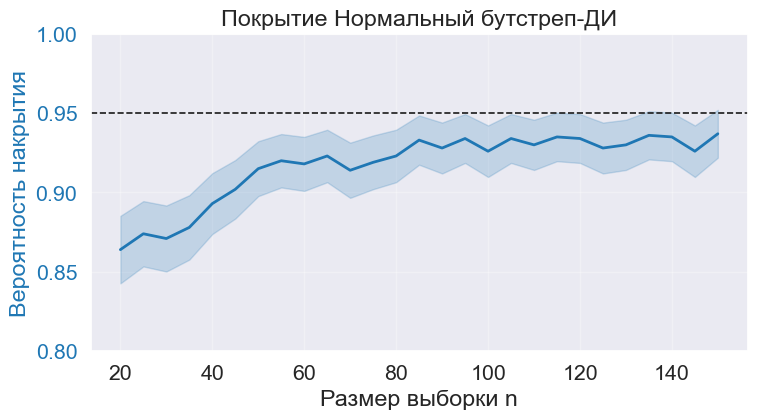

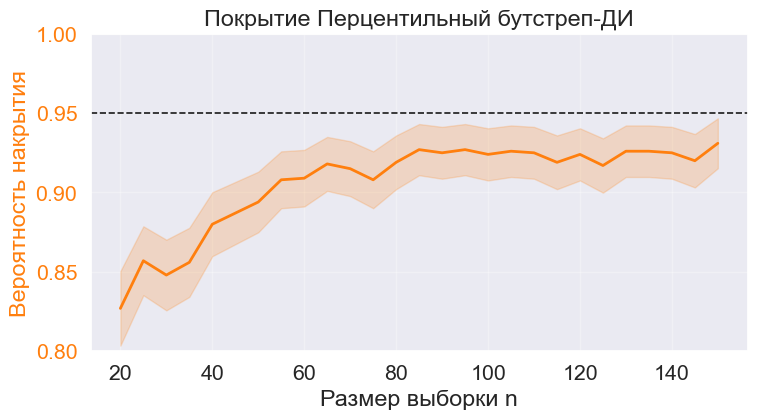

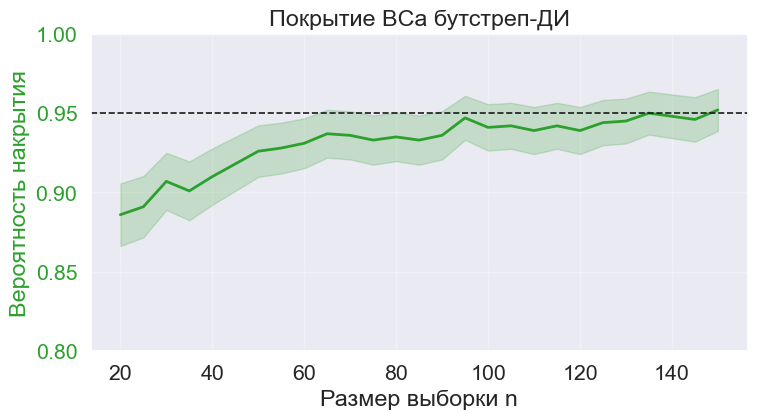

In [27]:
labels = ["Нормальный", "Перцентильный", "BCa"]
colors = ["tab:blue", "tab:orange", "tab:green"]
coverage = 1.0 - rejects

cov_L = np.empty_like(coverage)
cov_R = np.empty_like(coverage)

for j in range(3):
    for i in range(sample_size_grid.size):
        p_hat = coverage[i, j]
        k = int(round(p_hat * samples_num))
        Lp, Up, _ = confint_bern(k, samples_num, gamma=GAMMA)
        cov_L[i, j] = Lp
        cov_R[i, j] = Up


for j in range(3):
    fig, ax1 = plt.subplots(figsize=(8, 4.5))

    ax1.set_xlabel("Размер выборки n")
    ax1.set_ylabel("Вероятность накрытия", color=colors[j])
    ax1.plot(sample_size_grid, coverage[:, j], color=colors[j], lw=2, label="Покрытие")
    ax1.fill_between(sample_size_grid, cov_L[:, j], cov_R[:, j],
                     alpha=0.2, color=colors[j])
    ax1.axhline(GAMMA, ls="--", color="k", lw=1.2, label=f"Целевой уровень {GAMMA:.2f}")
    ax1.tick_params(axis="y", labelcolor=colors[j])
    ax1.set_ylim(0.8, 1.0)

    ax1.set_title(f"Покрытие {labels[j]} бутстреп-ДИ")
    ax1.grid(alpha=0.3)
    fig.tight_layout()
    plt.show()

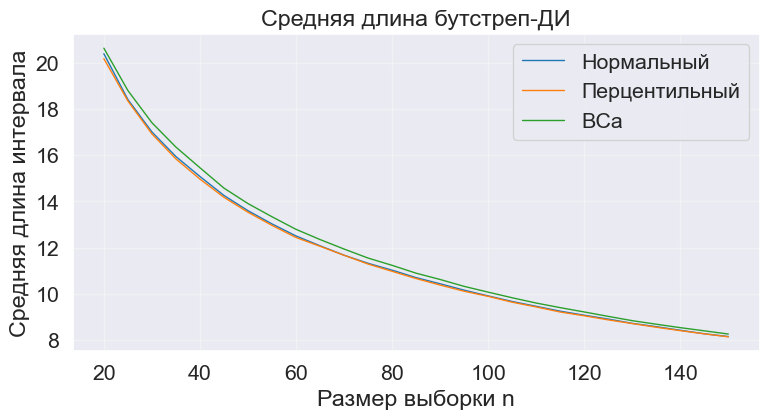

In [29]:
fig, ax = plt.subplots(figsize=(8, 4.5))
for j in range(3):
    ax.plot(sample_size_grid, lenghts[:, j], lw=1, label=labels[j], color=colors[j])
ax.set_xlabel("Размер выборки n")
ax.set_ylabel("Средняя длина интервала")
ax.set_title("Средняя длина бутстреп-ДИ")
ax.grid(alpha=0.3)
ax.legend()
fig.tight_layout()
plt.show()

Проанализируйте полученную картину и сделайте вывод.

**Вывод:**
1. Нормальный бутстреп выглядит самым легким с использовании и очевидно при $B \rightarrow \infty$ макимально приблизится к GAMMA, однако это требует многих вычислительных ресурсов(я даже уменьшил выборки до 1000). Из серьезных минусов вероятно плохо себя поведет на других распределениях, которые не симметричны
2. Перцентильный по сути также ведет себя как и нормальный, но лишен изъяна с несимметричными распределениями 
3. $BC_a$ - наш лидер, однако самый тяжелый в реализации и считается дольше, однако наиболее близок к уровню который мы хотим, к тому же при малых размерах выборки, он единственный корректен

## Задача 3

Эта задача посвящена *робастному* оцениванию. Это такой раздел статистики, который изучает, как сильно оценки зависят от выбросов и других *неверных* данных и как построить оценки, которые выдерживают шумы.

В этой задаче Вам предстоит:
- Научиться анализировать поведение простых оценок для распределений с "тяжёлыми хвостами" или при наличии выбросов и аномалий
- Изучить трейдофф между точностью и устойчивостью
- Научиться строить робастные оценки


Далее для всех графиков в этом задании используйте обозначенные цвета для каждого из распределений (даже если графики будут на разных осях). То есть если график касается нормального распределения, то рисуйте его синим цветом.

1) Постройте график теоретической плотности распределения для нормального распределения, распределения Лапласа и распределения Коши (во всех случаях неизвестным параметром является **сдвиг**.

2) Сгенерируйте по одной выборке достаточно большого размера из каждого распределения. Мы будем оценивать параметр сдвига каждого из распределений. Сделайте предположение о том, для каких распределений параметр сдвига будет оценён точнее при помощи среднего и медианы. Докажите Ваши предположения экспериментально. Моделировать оценки в этот раз не нужно, достаточно по одной выборке произвести оценивание и проверить его точность.

**Ответ:**

In [ ]:
# Эксперименты с оценкой средним и медианы


3) Часто в реальной жизни мы сталкиваемся с данными, в которых есть выбросы, возникшие, например, из-за опечаток. Пусть в выборке содержится 99 точек на интервале $[0;1]$ и один элемент, равный 300. Тогда среднее значение нашей выборки будет не меньше трех. Ясно, что так дело не пойдет, что же делать?

Можно использовать медиану или **усеченное среднее**.

**Усеченное среднее порядка $\alpha$** -- это среднее, составленное из выборки, от которой отрезаны $\alpha$- и $(1 - \alpha)$-квантили. Как ее получить?


1.   Отсортировать выборку
2.   Отрезать первые и последние ($\alpha \cdot \text{размер выборки}$) элементов выборки
3.   Посчитать среднее оставшихся значений

Напишите функцию для подсчёта этой статистики. Посчитайте усечённое среднее для сгенерированных выше выборок, но разных $\alpha$ и визулизируйте полученные значения. Оцените и изобразите распределение оценок для распределений выше и разных альфа. Как оно изменяется?

In [ ]:
def truncated_mean(sample, alpha=0.3):
    # YOUR CODE HERE
    return truncated_mean

4) Постройте график квадрата разности каждой из оценок и истинного значения параметра в зависимости от роста размера выборки для разных $\alpha$. Сделайте выводы, какие оценки точнее.

**Теорема**
Пусть распределение симметрично относительно нуля и имеет одну моду в нуле, тогда асимптотическая дисперсия усеченного среднего порядка $\alpha$ может быть выражена по формуле:
$$
\sigma^2(\alpha) = 2\cdot\frac{\int_0^{u_{1 - \alpha}} x^2 dF(x) + \alpha\cdot(u_{1 - \alpha})^2}{(1 - 2\alpha)^2},
$$

где $u_\alpha$ – квантиль порядка $\alpha$ распределения $F$.

Вычислите дисперсию и постройте график дисперсии в зависимости от $\alpha$.

*Подсказка.* Для численного интегрирования используйте функцию `quad` из модуля `scipy.integrate`

4.5) Дополнительный пункт на 5 баллов.

Докажите предложенную теорему.

5) Постройте графики для асимптотической дисперсии усечённого среднего в зависимости от $\alpha$ для всех трех распределений на разных осях (используйте `plt.subplots(1, 3, figsize=(21,7))`). Для заголовка графика используйте `ax[i].set_title`, для заголовка всей картинки используйте `fig.suptitle`.

6) *Breakdown point* в статистике неформально называется такое наименьшее число $x$ от 0 до 1, что если изменить больше $(100\cdot x)\%$ наблюдений выборки на выбросы, то оценка "пойдёт в разнос" и её значение может оказаться сколь угодно большим по модулю, как если бы вся выборка состояла из выбросов (более формальное определение см. на лекции).

Предположите, как Breakdown point усечённого среднего зависит от параметра $\alpha$.

Ответ:

Проверьте своё предположение моделированием. Будем считать, что вместо произвольных $(100\cdot x)\%$ выборки будет записано какое-то заранее подобранное достаточно большое число с положительным или отрицательным знаком.

Вывод.

8. Мы знаем, что существует Оценка Максимального Правдоподобия:

$\hat{\theta} = \mathrm{argmin}_{\theta}(-\log f_{\theta}(x))$, $f_{\theta}(x)$ --- правдоподобие выборки. В таком же виде можно выписать и оценки средним, медианой и усечённым средним:

$\hat{\theta} = \mathrm{argmin}_{\theta}(\sum_{i=1}^n\rho(x_i - \theta))$.

В общем случае, такая оценка называется обобщённой оценкой максимального правдоподобия или $M$-оценкой. Функция $\rho$ называется функцией влияния.

1) Как должна выглядеть функция $\rho$, чтобы результатом было усечённое среднее? *Указание*: "усекать" можно не только по квантилю, но и по числу

Ответ:

2) Эквивалентно задачу оптимизации можно писать в виде системы уравнений $(\sum_{i=1}^n\psi(x_i - \theta)) = 0$. Сравните два определения и скажите, какое из них шире (определяет больше возможных оценок) и как они связаны.

Ответ:

3) Самое интересное. Для распределения Коши постройте M-оценки для разных (хотя бы трёх) функций $\rho$ или $\psi$. Ищите максимум градиентным спуском, а ноль функции --- методом Ньютона.

Примеры функций влияния можно взять вот тут: https://en.wikipedia.org/wiki/Robust_statistics#M-estimators

3.5) Выразите усечённое среднее как L-оценку. Сравните усечённое среднее с его "винзоризованной" версией: в начале все элементы, большие $1-\alpha$-квантиля заменяем на значение этого квантиля (так же для меньших $\alpha$-квантиля) и затем усредняем. В этой оценке предлагается не выкидывать аномалии, а обрезать их. Предложите свои 1-2 L-оценки и сравните их с нашими.

Ответ:

4) Сравните (по точности предсказания) результаты, полученные для распределения Коши и разных функций влияния, а также для всех L-оценок.

5) Оцените Breakdown point предложенных оценок. Сравните результаты с теоретическими (см. лекцию). Сделайте вывод о том, как взаимосвязаны точность оценки и Breakdown point.

Сделайте единый вывод о робастном оценивании:

## Задача 4

И снова, реальные данные.

В этой задаче Вам предстоит применить на практике все изученные выше методы построения доверительных интервалов и робастных оценок.

Мы проанализируем изменение индекса качества воздуха (air quality index, AQI) для двух мегаполисов Индии за последние годы. Данные взяты с Kaggle (https://www.kaggle.com/rohanrao/air-quality-data-in-india)

In [ ]:
!gdown https://drive.google.com/file/d/1hvODMPkJPe0HLIGq8RgClN1_RSw2gfD-

1. Загрузите файл `city_day.csv`. Нам понадобятся столбцы `City`, `Date` и `AQI`. При этом учтите, что:
* В дальнейшем мы будем работать с датами, поэтому используйте аргумент `parse_dates` чтобы корректо их распарсить
* Данные содержат пропуски, которые нужно удалить

Для удобства сохраните в отдельные поля `Month` и `Year` соответственно год и месяц, когда производились замеры

Нас будут интересовать два города: Мумбаи (Mumbai) и Калькутта (Kolkata). Сохраните данные по этим двум городам для всех дней с 1 июля 2018 года включительно

2. Изучите выборки значения **AQI** для месяцев с июля 2018-го по июнь 2020-го годов на предмет наличия аномалий или выбросов и предложите хорошую оценку для "среднего значения" этого распределения. Это не обязательно должно быть среднее по выборке. Визуализируйте оценки для каждого города и месяца в удобном виде и сделайте по ним выводы.

Для каждого месяца с июля 2018 по июнь 2020 включительно постройте бутстрепный доверительный интервал для __среднего значения AQI__. Тип интервала выберите сами, например, изучив распределение среднегомесячного значения по данным до июля 2018 года или на основании результатов задачи 2. Учтите: на этот раз реализовать интервал нужно **самостоятельно**.

Постройте на одном графике доверительные интервалы для Мумбаи и Калькутты. Также отметьте точками на графике истинный средний AQI и соедините точки линиями. Проследите за тем, чтобы графики, относящиеся к одному городу, были одного цвета.

Посмотрите на получившийся график. Видны ли в нем какие-либо закономерности? С чем они могут быть связаны?

Вывод:

4. Теперь давайте сравним качество воздуха в апреле 2019 и апреле 2020 годов. Постройте __на одном графике__
* доверительные интервалы для апреля 2019 и апреля 2020 для Мумбаи
* истинные средние значения (с помощью `plt.hlines`)

Проследите за тем, чтобы графики, относящиеся к одному городу, были одного цвета.

Сделайте выводы. Что можно сказать про доверительные интервалы в каждом из случаев? Какие прикладные выводы о загрязнении воздуха можно сделать из Ваших результатов? Подумайте о том, почему некорректно делать выводы о том, где чище воздух только исходя из сравнения оценок показателей качества, и приходится сравнивать интервалы.